### APP, partie oculomotrice

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt

path="C:/Python/APP_M1_Archive"

chemin_fichier = "C:/Python/APP_M1/Archive/2026/sub-03/ses-01/beh/sub-03_task-DoubleDriftPerception_data.csv"
df = pd.read_csv(chemin_fichier)



## Code pour le sujet 3

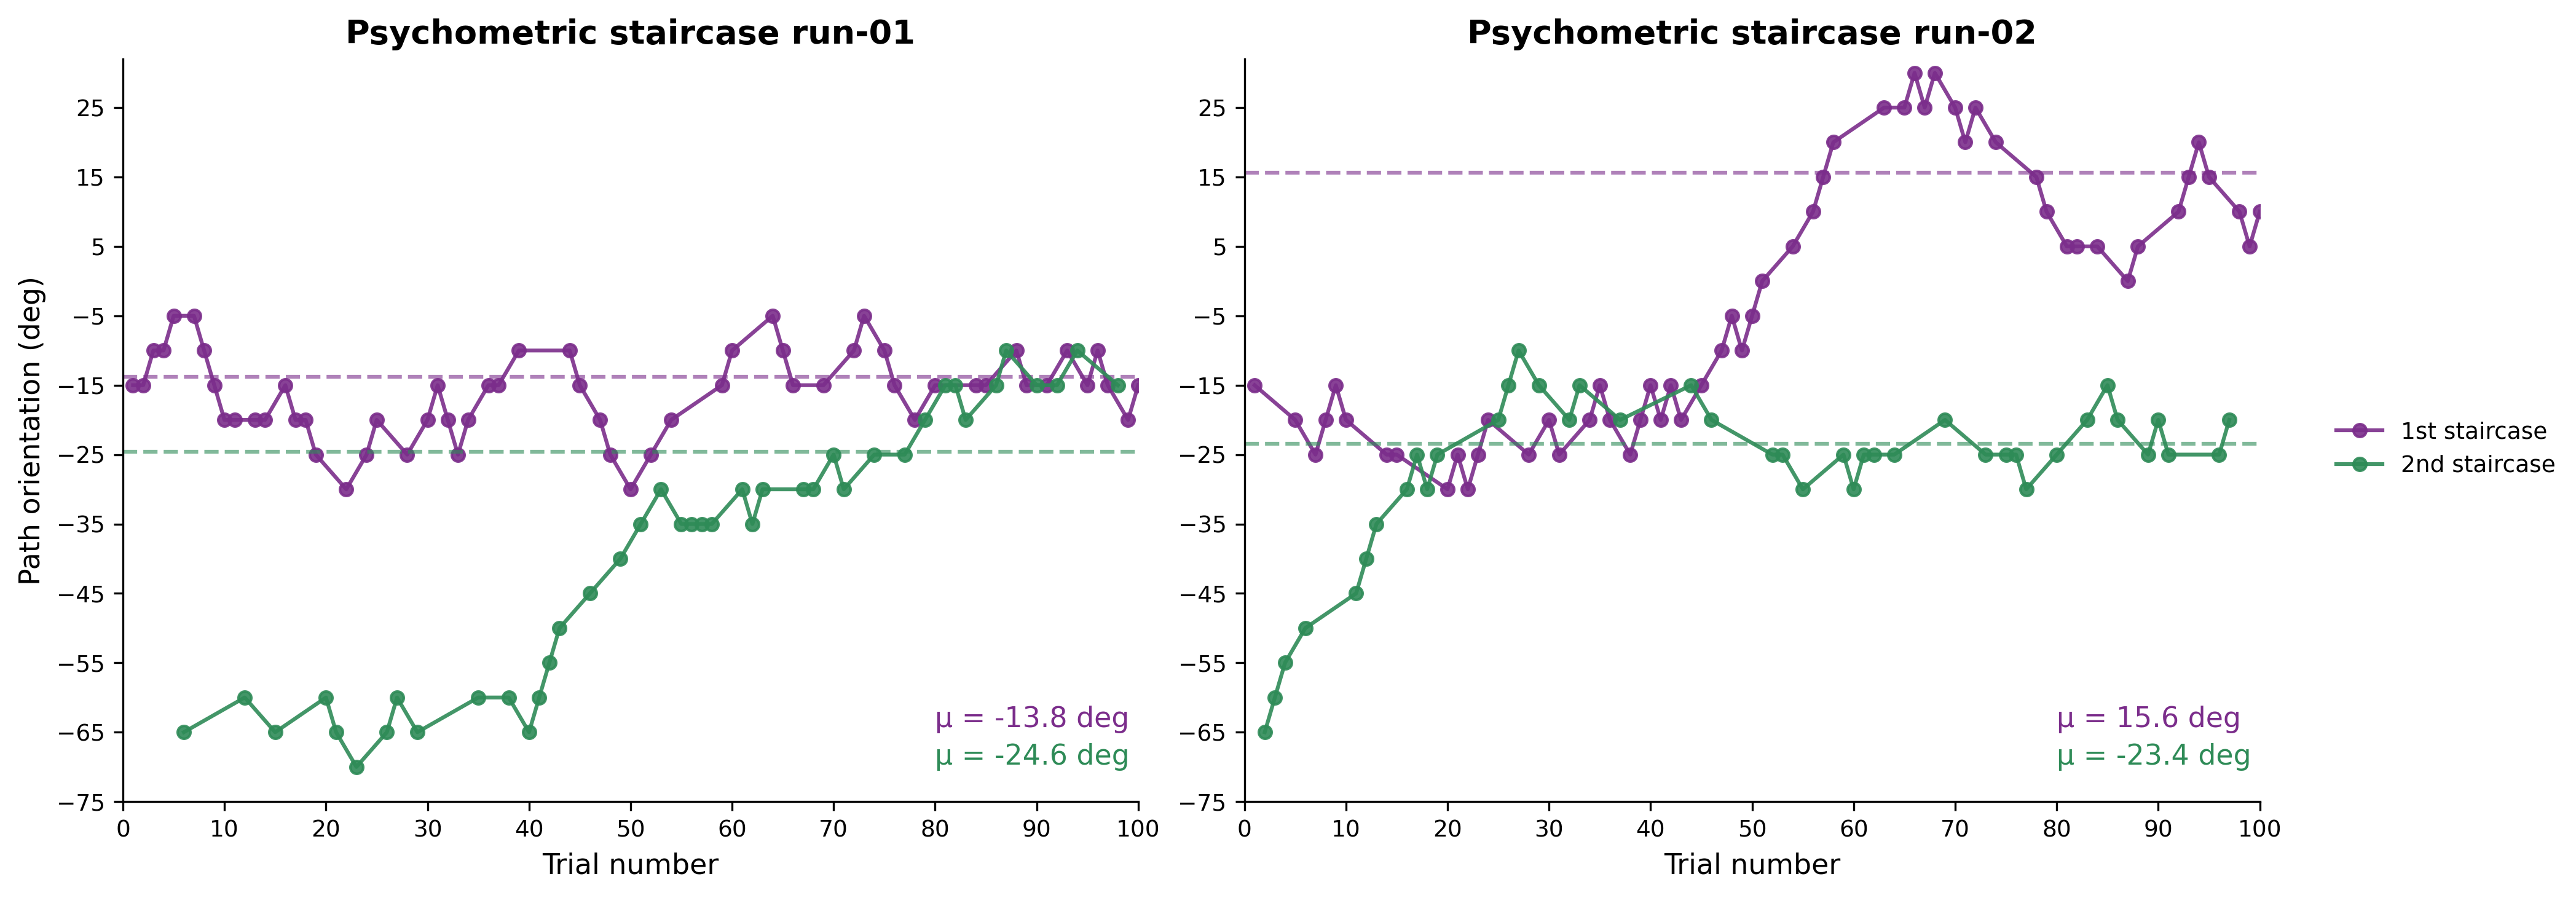

In [ ]:
# --- TES PRÉFÉRENCES ESTHÉTIQUES GLOBALES ---
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False 
plt.rcParams['axes.spines.right'] = False 
plt.rcParams['axes.spines.left'] = True 
plt.rcParams['axes.spines.bottom'] = True 
plt.rcParams['axes.grid'] = False 
plt.rcParams['legend.frameon'] = False 
plt.rcParams['legend.loc'] = 'best' 
plt.rcParams['legend.title_fontsize'] = 11
plt.rcParams['xtick.labelsize'] = 9  
plt.rcParams['ytick.labelsize'] = 9  
plt.rcParams['legend.fontsize'] = 9 
plt.rcParams['figure.titlesize'] = 15  
plt.rcParams['axes.titlesize'] = 13  
plt.rcParams['axes.labelsize'] = 11  
# --------------------------------------------

sujet = "sub-03"
chemin_fichier = f"C:/Python/APP_M1/Archive/2026/{sujet}/ses-01/beh/{sujet}_task-DoubleDriftPerception_data.csv"
df = pd.read_csv(chemin_fichier)

colors = {1: '#7B2D8B', 2: '#2E8B57'} 
labels = {1: '1st staircase', 2: '2nd staircase'}

runs = df['run_number'].unique()

fig, axes = plt.subplots(1, len(runs), figsize=(14, 5), sharey=True)

for i, run in enumerate(runs):
    ax = axes[i]
    df_run = df[df['run_number'] == run]
    
    for s_id in df_run['staircase_num'].unique():
        subset = df_run[df_run['staircase_num'] == s_id]
        
        # Tracer l'escalier
        ax.plot(subset['trial_number'], subset['ext_mot_ori'], '-o', 
                 color=colors.get(s_id), label=labels.get(s_id),
                 markersize=5, alpha=0.9)
        
        # Tracer la moyenne
        final_mu = subset['ext_mot_ori'].tail(25).mean()
        ax.axhline(y=final_mu, color=colors.get(s_id), linestyle='--', alpha=0.6)
        
        y_pos = 0.10 if s_id == 1 else 0.05
        ax.text(0.80, y_pos, f'μ = {final_mu:.1f} deg', transform=ax.transAxes, color=colors.get(s_id))

    # Titres et esthétique
    ax.set_title(f'Psychometric staircase run-{int(run):02d}', fontweight='bold')
    ax.set_xlabel('Trial number')
    
    # Axe Y fixe avec la graduation personnalisée
    ax.set_ylim(-75, 32)
    ax.set_yticks(range(-75, 32, 10)) 
    ax.tick_params(labelleft=True)   
    ax.set_xlim(0, 100) 
    ax.set_xticks(range(0, 101, 10)) 
    
    if i == 0:
        ax.set_ylabel('Path orientation (deg)')

# Légende
handles, leg_labels = ax.get_legend_handles_labels()
fig.legend(handles, leg_labels, loc='center right')

plt.tight_layout()
plt.subplots_adjust(right=0.88)

plt.show()

#regarder comment save auto, et calculer les m moy a travers les stracase et les runs 
#faire un plot avec les moyennes des 5 suj 

## Code pour le sujet 4 

In [ ]:


# 1. Charger les données du Sujet 04
# (Assure-toi que le chemin correspond bien à ton dossier)
df_04 = pd.read_csv('sub-04_task-DoubleDriftPerception_data.csv')

colors = {1: '#1f77b4', 2: '#d62728'} 
labels = {1: '1st staircase', 2: '2nd staircase'}
runs = df_04['run_number'].unique()

fig, axes = plt.subplots(1, len(runs), figsize=(14, 5), sharey=True)

for i, run in enumerate(runs):
    ax = axes[i]
    df_run = df_04[df_04['run_number'] == run]
    
    for s_id in df_run['staircase_num'].unique():
        subset = df_run[df_run['staircase_num'] == s_id]
        
        # Tracé des points
        ax.plot(subset['trial_number'], subset['ext_mot_ori'], '-o', 
                 color=colors.get(s_id), label=labels.get(s_id),
                 markersize=5, alpha=0.9)
        
        # Ligne de moyenne
        final_mu = subset['ext_mot_ori'].tail(20).mean()
        ax.axhline(y=final_mu, color=colors.get(s_id), linestyle='--', alpha=0.6)
        
        # Texte fixe en bas à droite
        y_pos = 0.15 if s_id == 1 else 0.05
        ax.text(0.70, y_pos, f'μ = {final_mu:.1f} deg', 
                transform=ax.transAxes, 
                color=colors.get(s_id))

    # Esthétique et Titres
    ax.set_title(f'Psychometric staircase sub-04 | run-{int(run):02d}')
    ax.set_xlabel('Trial number')
    
    # Axe Y de -75 à 32 avec pas de 10
    ax.set_ylim(-75, 32)
    ax.set_yticks(range(-75, 32, 10)) 
    ax.tick_params(labelleft=True)   
    
    # Axe X de 0 à 100 avec pas de 10
    ax.set_xlim(0, 100)
    ax.set_xticks(range(0, 101, 10))
    
    if i == 0:
        ax.set_ylabel('Path orientation (deg)')

handles, leg_labels = ax.get_legend_handles_labels()
fig.legend(handles, leg_labels, loc='center right')

plt.tight_layout()
plt.subplots_adjust(right=0.88)
plt.savefig('staircase_plot_sub-04.png') # Sauvegarde spécifique au sujet
plt.show()

## Code pour le sujet 5 